#**WEEK 8 INTRODUCTION**

#Week 8 is the final stage of the HealthConnect project.

The project has progressed through:

- Week 4 — Problem Understanding, Resource Review and Planning
- Week 5 — Analysis, Development and Initial Implementation
- Week 6 — Integration, Advanced Development and Validation
- Week 7 — Testing, Refinement and End-to-End Validation
- Week 8 — Final Integration, Documentation and Presentation

This notebook continues directly from the completed Week 7 Data Science work.

The purpose of Week 8 is NOT to restart the modelling process.

Instead, this notebook:

1. Reviews the Week 7 testing and refinement results.
2. Confirms the final Data Science model.
3. Evaluates the final model against the original baseline.
4. Documents the final model and modelling decisions.
5. Summarises final errors and important limitations.
6. Explains business suitability.
7. Documents what the model can and cannot be used for.
8. Incorporates validated findings from other tracks where evidence
   is available.
9. Defines the information required by ML Engineering.
10. Documents HC-POD integration.
11. Defines the final HealthConnect workflow.
12. Prepares the Data Science contribution for the final presentation.
13. Documents lessons learned and future improvements.
14. Provides a final Week 8 requirements coverage matrix.

# ***Week 7 → Week 8 Transition***


## 1. Main Week 7 output

The main Week 7 output was a tested and refined Random Forest
candidate for HealthConnect appointment No-Show prediction.


## 2. Most important testing result

The most important testing result was the comparison of the refined
candidate against the previous candidate using held-out evaluation,
cross-validation and error analysis.


## 3. Major issue discovered during testing

The main modelling issue identified was the presence of residual
prediction errors, including false positives and false negatives.
This demonstrated that model predictions should be treated as
probabilistic decision-support signals rather than certainties.


## 4. What was refined or improved?

The modelling process included refinement of the Random Forest
configuration, threshold analysis, feature review and retesting.


## 5. Which component is now considered ready?

The final Data Science prediction component is considered ready for
documented integration.


## 6. What still needs to be integrated?

The final model output needs to be connected with the other
HealthConnect project components and the operational workflow.


## 7. Which tracks are involved?

The relevant multidisciplinary tracks are:

- Data Analytics
- Data Science
- ML Engineering
- Generative AI
- Project Management


## 8. What will be demonstrated during the final presentation?

The presentation will demonstrate the Data Science contribution,
model results, testing and refinement, cross-track dependencies,
business value, limitations and how the model contributes to the
overall HealthConnect solution.

#**IMPORT LIBRARIES**

In [1]:
import warnings
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (train_test_split,StratifiedKFold,cross_validate)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (OneHotEncoder,StandardScaler)
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report,confusion_matrix,ConfusionMatrixDisplay,roc_curve,precision_recall_curve)
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid")
print("Week 8 libraries imported successfully.")

Week 8 libraries imported successfully.


##**LOADING DATASETS**

In [2]:
ml_ready_dataset = pd.read_csv('HealthConnect_ML_Ready_Dataset.csv')
cleaned_df = pd.read_csv('HealthConnect_Week5_Cleaned_Model_Dataset.csv')
week6_model_results = pd.read_csv('HealthConnect_Week6_Model_Comparison.csv')
week6_cv_results = pd.read_csv('HealthConnect_Week6_Cross_Validation.csv')
week6_threshold_rf = pd.read_csv('HealthConnect_Week6_RandomForest_Threshold_Analysis.csv')
week6_candidate_errors = pd.read_csv('HealthConnect_Week6_Candidate_Error_Analysis.csv')
week6_summary = pd.read_csv('HealthConnect_Week6_Summary.csv')
display(week6_model_results)
display(week6_cv_results)
display(week6_threshold_rf.head(20))
display(week6_candidate_errors.head(10))
print(ml_ready_dataset.shape)
print(print(cleaned_df.shape))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Week 5 Logistic Regression,0.539030,0.553812,0.509278,0.530612,0.543277
1,Week 6 Improved Logistic Regression,0.611814,0.613592,0.651546,0.632000,0.632874
2,Week 6 Random Forest,0.619198,0.620155,0.659794,0.639361,0.656351


,Model,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Recall Mean,CV F1 Mean,CV ROC-AUC Mean,CV ROC-AUC Std
0,Improved Logistic Regression,0.609878,0.007725,0.620238,0.612890,0.616226,0.647075,0.007523
1,Random Forest,0.631409,0.016596,0.643244,0.627325,0.634965,0.666504,0.008885


,Threshold,Precision,Recall,F1 Score,Accuracy,No-Show Flags
0,0.10,0.511603,1.000000,0.676902,0.511603,948
1,0.15,0.511603,1.000000,0.676902,0.511603,948
2,0.20,0.511603,1.000000,0.676902,0.511603,948
3,0.25,0.512144,1.000000,0.677374,0.512658,947
4,0.30,0.517094,0.997938,0.681210,0.522152,936
5,0.35,0.531915,0.979381,0.689405,0.548523,893
6,0.40,0.554293,0.905155,0.687549,0.579114,792
7,0.45,0.583975,0.781443,0.668430,0.603376,649
8,0.50,0.620155,0.659794,0.639361,0.619198,516
9,0.55,0.640957,0.496907,0.559814,0.600211,376


,previous_no_shows,waiting_time_minutes,appointment_day,appointment_date,appointment_time,reminder_sent,appointment_type,booking_lead_days,distance_to_clinic_km,age,gender,actual_no_show,predicted_no_show,predicted_probability,prediction_type
0,0,21.0,Friday,2025-06-13,Morning,Yes,Follow-up,24,2.4,24,Female,1,1,0.365232,True Positive
1,0,31.0,Saturday,2025-05-24,Morning,Yes,General Consultation,29,12.6,64,Male,0,1,0.381933,False Positive
2,1,14.0,Saturday,2026-01-10,Afternoon,Yes,Follow-up,41,16.7,18,Male,1,1,0.617480,True Positive
3,0,12.0,Friday,2025-04-25,Morning,Yes,Diagnostic Test,43,3.1,65,Male,1,1,0.515091,True Positive
4,1,25.0,Friday,2026-04-03,Afternoon,Yes,General Consultation,34,14.9,62,Male,1,1,0.551607,True Positive
5,0,31.0,Sunday,2025-03-16,Morning,Yes,General Consultation,41,6.7,40,Female,0,1,0.543537,False Positive
6,0,19.0,Monday,2026-05-18,Morning,Yes,Follow-up,11,23.8,19,Male,1,1,0.496870,True Positive
7,1,2.0,Friday,2026-06-05,Morning,Yes,General Consultation,31,10.3,55,Female,0,1,0.504294,False Positive
8,0,15.0,Saturday,2025-07-05,Afternoon,No,General Consultation,19,5.6,37,Male,0,1,0.395698,False Positive
9,0,34.0,Friday,2026-04-10,Morning,Yes,Follow-up,46,13.0,60,Male,0,1,0.595002,False Positive


(4737, 5)
(4737, 23)
None


#**FINAL COMPONENT READINESS**

## Part 1 — Final Integration Readiness

### Final Data Science component

-The final Data Science component is the HealthConnect appointment
No-Show prediction model.

### Problem addressed

-The model supports identification of appointments with elevated
predicted No-Show probability so that HealthConnect can prioritise
appropriate administrative support.

### Current status

The model has progressed through:
- baseline development
- feature refinement
- candidate model development
- cross-validation
- threshold analysis
- error analysis
- segment testing
- robustness testing
- refinement
- retesting

-Week 8 converts the validated modelling work into the final documented
Data Science package.

### Important boundary
-The model predicts risk. It does not establish certainty that a
patient will miss an appointment.

#**DEFINE TARGET**

In [3]:
TARGET = "no_show"
if TARGET not in ml_ready_dataset.columns:
    raise KeyError("'no_show' target was not found in the HealthConnect ML-ready dataset.")
print("Target:", TARGET)
target_distribution = (ml_ready_dataset[TARGET].value_counts().rename(index={0: "Attended",1: "No-Show"}).to_frame("Count"))
target_distribution["Percentage"] = (target_distribution["Count"]/ target_distribution["Count"].sum()* 100).round(2)
display(target_distribution)

Target: no_show


,Count,Percentage
no_show,,
No-Show,2423,51.15
Attended,2314,48.85


#**WEEK 7 → WEEK 8 SUMMARY**

-The following table is designed to provide a concise transition from
Week 7 into the final Week 8 stage.

-The values are populated from the completed Week 7 modelling process
where possible.

#**RECONSTRUCT WEEK 7 MODELLING FEATURES**

In [4]:
week5_features = [column for column in ml_ready_dataset.columns if column != TARGET]
possible_week6_features = ["previous_no_shows","waiting_time_minutes","appointment_date","appointment_time","appointment_day","reminder_sent","appointment_type","booking_lead_days","distance_to_clinic_km","age","gender"]
leakage_keywords = ["outcome","status","attendance","attended","no_show","final","post"]
refined_features = week5_features.copy()
if cleaned_df is not None:
    for column in possible_week6_features:
        if column not in cleaned_df.columns:
            continue
        normalized = re.sub(r"[^a-z0-9]","",column.lower())
        possible_leakage = any(keyword in normalized for keyword in leakage_keywords)
        if (not possible_leakage and column not in refined_features):refined_features.append(column)
refined_features = list(dict.fromkeys(refined_features))
if "Unnamed: 0" in refined_features:
    refined_features.remove("Unnamed: 0")
available_refined_features = [feature for feature in refined_features if feature in cleaned_df.columns]
print("Final modelling features carried forward:")
for feature in available_refined_features:
    print("-", feature)
print("\nNumber of features:",len(available_refined_features))

Final modelling features carried forward:
- previous_no_shows
- waiting_time_minutes
- appointment_day
- appointment_date
- appointment_time
- reminder_sent
- appointment_type
- booking_lead_days
- distance_to_clinic_km
- age
- gender

Number of features: 11


#**BUILD FINAL MODELLING DATASET**

In [5]:
refined_df = cleaned_df[available_refined_features + [TARGET]].copy()
refined_df = refined_df.dropna(subset=[TARGET])
X = refined_df[available_refined_features].copy()
y = refined_df[TARGET].copy()
print("Final modelling dataset:")
print(refined_df.shape)

Final modelling dataset:
(4737, 12)


#**REPRODUCIBLE FINAL TRAIN/TEST SPLIT**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 3789
Testing observations: 948


#**CREATE PREPROCESSOR**

In [7]:
numeric_features = (X_train.select_dtypes(include=np.number).columns.tolist())
categorical_features = (X_train.select_dtypes(include=["object","category","bool","string"]).columns.tolist())
numeric_transformer = Pipeline(steps=[("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())])
categorical_transformer = Pipeline(steps=[("imputer",SimpleImputer(strategy="most_frequent")),("onehot",OneHotEncoder(handle_unknown="ignore",sparse_output=False))])
preprocessor = ColumnTransformer(transformers=[("numeric",numeric_transformer,numeric_features),("categorical",categorical_transformer,categorical_features)],remainder="drop")
print("Final model preprocessor created successfully.")

Final model preprocessor created successfully.


#**FINAL MODEL SELECTION LOGIC**

Week 7 tested two Random Forest configurations:

1. Week 6 candidate Random Forest
2. Week 7 refined Random Forest

The refined model was subjected to:
- held-out test evaluation
- training/test comparison
- five-fold cross-validation
- error comparison
- refinement acceptance criteria
- retesting

Week 8 does not introduce an unrelated algorithm.

The final candidate is selected from the models already tested during
Week 7.

The selection is evidence-based rather than based on an arbitrary
single metric.

#**REBUILD WEEK 6 CANDIDATE MODEL**

In [8]:
candidate_model = Pipeline(steps=[("preprocessor",preprocessor),("classifier",RandomForestClassifier(n_estimators=300,max_depth=None,min_samples_split=5,min_samples_leaf=2,class_weight="balanced",random_state=42,n_jobs=-1))])
candidate_model.fit(X_train,y_train)
candidate_probabilities = (candidate_model.predict_proba(X_test)[:, 1])
candidate_train_probabilities = (candidate_model.predict_proba(X_train)[:, 1])
print("Week 6 candidate candidate model reconstructed.")

Week 6 candidate candidate model reconstructed.


#**REBUILD WEEK 7 REFINED MODEL**

In [9]:
refined_candidate_model = Pipeline(steps=[("preprocessor",preprocessor),("classifier",RandomForestClassifier(n_estimators=300,max_depth=12,min_samples_split=5,min_samples_leaf=2,class_weight="balanced",random_state=42,n_jobs=-1))])
refined_candidate_model.fit(X_train,y_train)
refined_probabilities = (refined_candidate_model.predict_proba(X_test)[:, 1])
refined_train_probabilities = (refined_candidate_model.predict_proba(X_train)[:, 1])
print("Week 7 refined model reconstructed.")

Week 7 refined model reconstructed.


#**DETERMINE OPERATIONAL THRESHOLD**

In [10]:
if "Threshold" in week6_threshold_rf.columns:
    threshold_candidates = (week6_threshold_rf.sort_values(["F1 Score","Recall"],ascending=False))
    selected_threshold = float(threshold_candidates.iloc[0]["Threshold"])
else:
    selected_threshold = 0.50
print("Operational threshold carried forward:",0.50)

Operational threshold carried forward: 0.5


#**METRIC FUNCTION**

In [11]:
def calculate_metrics(model_name,y_true,probabilities,threshold=0.50):
    predictions = (probabilities >= threshold).astype(int)
    return {"Model": model_name,"Threshold": threshold,"Accuracy": accuracy_score(y_true,predictions),"Precision": precision_score(y_true,predictions,zero_division=0),"Recall": recall_score(y_true,predictions,zero_division=0),"F1 Score": f1_score(y_true,predictions,zero_division=0),"ROC-AUC": roc_auc_score(y_true,probabilities),"No-Show Flags": int(predictions.sum())}

#**EVALUATE WEEK 7 CANDIDATE AND REFINED MODEL**

In [12]:
candidate_metrics = calculate_metrics("Week 6 Random Forest Candidate",y_test,candidate_probabilities,0.35)
refined_metrics = calculate_metrics("Week 7 Refined Random Forest",y_test,refined_probabilities,0.50)
model_comparison = pd.DataFrame([candidate_metrics,refined_metrics])
display(model_comparison.round(4))

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC,No-Show Flags
0,Week 6 Random Forest Candidate,0.35,0.5485,0.5319,0.9794,0.6894,0.6564,893
1,Week 7 Refined Random Forest,0.50,0.6266,0.6287,0.6598,0.6439,0.6567,509


#**TRAINING PERFORMANCE**

In [13]:
candidate_train_metrics = calculate_metrics("Week 6 Candidate — Training",y_train,candidate_train_probabilities,0.35)
refined_train_metrics = calculate_metrics("Week 7 Refined — Training",y_train,refined_train_probabilities,0.50)
training_test_comparison = pd.DataFrame([candidate_train_metrics,candidate_metrics,refined_train_metrics,refined_metrics])
display(training_test_comparison.round(4))

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC,No-Show Flags
0,Week 6 Candidate — Training,0.35,0.6081,0.5666,0.9943,0.7219,0.8508,3401
1,Week 6 Random Forest Candidate,0.35,0.5485,0.5319,0.9794,0.6894,0.6564,893
2,Week 7 Refined — Training,0.50,0.6941,0.7097,0.6801,0.6946,0.7704,1857
3,Week 7 Refined Random Forest,0.50,0.6266,0.6287,0.6598,0.6439,0.6567,509


#**CROSS-VALIDATION**

In [14]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_scoring = {"accuracy": "accuracy","precision": "precision","recall": "recall","f1": "f1","roc_auc": "roc_auc"}
candidate_cv_scores = cross_validate(candidate_model,X,y,cv=cv,scoring=cv_scoring,n_jobs=-1)
refined_cv_scores = cross_validate(refined_candidate_model,X,y,cv=cv,scoring=cv_scoring,n_jobs=-1)
cv_comparison = pd.DataFrame({"Model": ["Week 6 Candidate Random Forest","Week 7 Refined Random Forest"
    ],
    "CV Accuracy Mean": [
        candidate_cv_scores["test_accuracy"].mean(),
        refined_cv_scores["test_accuracy"].mean()
    ],
    "CV Precision Mean": [
        candidate_cv_scores["test_precision"].mean(),
        refined_cv_scores["test_precision"].mean()
    ],
    "CV Recall Mean": [
        candidate_cv_scores["test_recall"].mean(),
        refined_cv_scores["test_recall"].mean()
    ],
    "CV F1 Mean": [
        candidate_cv_scores["test_f1"].mean(),
        refined_cv_scores["test_f1"].mean()
    ],
    "CV ROC-AUC Mean": [
        candidate_cv_scores["test_roc_auc"].mean(),
        refined_cv_scores["test_roc_auc"].mean()
    ],
    "CV ROC-AUC Std": [
        candidate_cv_scores["test_roc_auc"].std(),
        refined_cv_scores["test_roc_auc"].std()]})
display(cv_comparison.round(4))

,Model,CV Accuracy Mean,CV Precision Mean,CV Recall Mean,CV F1 Mean,CV ROC-AUC Mean,CV ROC-AUC Std
0,Week 6 Candidate Random Forest,0.6314,0.6432,0.6273,0.635,0.6665,0.0089
1,Week 7 Refined Random Forest,0.6295,0.6486,0.6013,0.624,0.6635,0.0080


#**RECREATE WEEK 7 REFINEMENT ACCEPTANCE TEST**

In [15]:
recall_change = (
    refined_metrics["Recall"]
    - candidate_metrics["Recall"]
)

f1_change = (
    refined_metrics["F1 Score"]
    - candidate_metrics["F1 Score"]
)

auc_change = (
    refined_metrics["ROC-AUC"]
    - candidate_metrics["ROC-AUC"]
)

candidate_gap = abs(
    candidate_train_metrics["ROC-AUC"]
    - candidate_metrics["ROC-AUC"]
)

refined_gap = abs(
    refined_train_metrics["ROC-AUC"]
    - refined_metrics["ROC-AUC"]
)

gap_reduction = (
    candidate_gap
    - refined_gap
)

acceptable_recall = (
    recall_change >= -0.02
)

acceptable_f1 = (
    f1_change >= -0.02
)

acceptable_auc = (
    auc_change >= -0.02
)

meaningful_change = (
    f1_change >= 0.01
    or
    auc_change >= 0.01
    or
    gap_reduction >= 0.02
)
refinement_accepted = (
    acceptable_recall
    and
    acceptable_f1
    and
    acceptable_auc
    and
    meaningful_change
)
refinement_decision = pd.DataFrame([{
    "Recall Change": recall_change,
    "F1 Change": f1_change,
    "ROC-AUC Change": auc_change,
    "ROC-AUC Gap Reduction": gap_reduction,
    "Refinement Accepted": refinement_accepted}])
display(refinement_decision.round(4))

,Recall Change,F1 Change,ROC-AUC Change,ROC-AUC Gap Reduction,Refinement Accepted
0,-0.3196,-0.0455,0.0003,0.0807,False


#**FINAL MODEL DECISION**

The final candidate model is selected using the Week 7 testing evidence.

If the Week 7 refined Random Forest met the documented technical
screening criteria, it becomes the final Data Science candidate.

If the refinement did not meet those criteria, the original Week 6
candidate is retained.

This prevents the final model from being selected merely because it is
newer.

#**SELECT FINAL MODEL**

In [16]:
if refinement_accepted:
    final_model_name = "HealthConnect Final Random Forest — Week 7 Refined"
    final_model = refined_candidate_model
    final_probabilities = refined_probabilities
    final_train_probabilities = refined_train_probabilities
    final_metrics = refined_metrics
    final_train_metrics = refined_train_metrics
    final_cv_scores = refined_cv_scores
    final_source = ("Week 7 refined Random Forest because the documented ""technical refinement screening criteria were satisfied.")
else:
    final_model_name = "HealthConnect Final Random Forest — Week 6 Candidate"
    final_model = candidate_model
    final_probabilities = candidate_probabilities
    final_train_probabilities = candidate_train_probabilities
    final_metrics = candidate_metrics
    final_train_metrics = candidate_train_metrics
    final_cv_scores = candidate_cv_scores
    final_source = ("Week 6 candidate Random Forest retained because the Week 7 ""refinement did not satisfy the documented technical screening criteria.")
print("FINAL MODEL:")
print(final_model_name)
print("\nSelection basis:")
print(final_source)

FINAL MODEL:
HealthConnect Final Random Forest — Week 6 Candidate

Selection basis:
Week 6 candidate Random Forest retained because the Week 7 refinement did not satisfy the documented technical screening criteria.


#**FINAL MODEL PERFORMANCE TABLE**

In [17]:
final_performance = pd.DataFrame([{"Final Model": final_model_name,"Threshold": selected_threshold,"Accuracy": final_metrics["Accuracy"],"Precision": final_metrics["Precision"],"Recall": final_metrics["Recall"],"F1 Score": final_metrics["F1 Score"],"ROC-AUC": final_metrics["ROC-AUC"],"No-Show Flags": final_metrics["No-Show Flags"]}])
display(final_performance.round(4))

,Final Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC,No-Show Flags
0,HealthConnect Final Random Forest — Week 6 Can...,0.35,0.5485,0.5319,0.9794,0.6894,0.6564,893


#**FINAL MODEL INTERPRETATION**

The final model should be interpreted using multiple measures.

Accuracy describes the proportion of correct classifications.

Precision describes the proportion of appointments flagged as No-Show
that were actually No-Shows.

Recall describes the proportion of observed No-Shows identified by the
model.

F1 combines precision and recall.

ROC-AUC describes the model's ability to distinguish between the two
classes across probability thresholds.

No single metric is sufficient to determine operational suitability.

The selected threshold controls the classification trade-off and is
therefore part of the operational model specification.

#**FINAL BASELINE RECONSTRUCTION**

In [18]:
baseline_features = [column for column in ml_ready_dataset.columns if column != TARGET]
X_baseline = ml_ready_dataset[baseline_features].copy()
y_baseline = ml_ready_dataset[TARGET].copy()
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_baseline,y_baseline,test_size=0.20,random_state=42,stratify=y_baseline)
numeric_features_b = (X_train_b.select_dtypes(include=np.number).columns.tolist())
categorical_features_b = (X_train_b.select_dtypes(include=["object","category","bool","string"]).columns.tolist())
numeric_transformer_b = Pipeline(steps=[("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())])
try:
    onehot_encoder_b = OneHotEncoder(handle_unknown="ignore",sparse_output=False)
except TypeError:
    onehot_encoder_b = OneHotEncoder(handle_unknown="ignore",sparse=False)
categorical_transformer_b = Pipeline(steps=[("imputer",SimpleImputer(strategy="most_frequent")),("onehot",onehot_encoder_b)])
baseline_preprocessor = ColumnTransformer(transformers=[("numeric",numeric_transformer_b,numeric_features_b),("categorical",categorical_transformer_b,categorical_features_b)],remainder="drop")
baseline_model = Pipeline(steps=[("preprocessor",baseline_preprocessor),("classifier",LogisticRegression(max_iter=1000,random_state=42))])
baseline_model.fit(X_train_b,y_train_b)
baseline_probabilities = (baseline_model.predict_proba(X_test_b)[:, 1])
baseline_metrics = calculate_metrics("Week 5 Logistic Regression Baseline",y_test_b,baseline_probabilities,0.35)
print("Week 5 baseline reconstructed.")
display(pd.DataFrame([baseline_metrics]).round(4))

Week 5 baseline reconstructed.


,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC,No-Show Flags
0,Week 5 Logistic Regression Baseline,0.35,0.5116,0.5116,1.0,0.6769,0.5434,948


#**BASELINE VS FINAL**

In [19]:
baseline_final_comparison = pd.DataFrame([baseline_metrics,final_metrics])
display(baseline_final_comparison.round(4))

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC,No-Show Flags
0,Week 5 Logistic Regression Baseline,0.35,0.5116,0.5116,1.0000,0.6769,0.5434,948
1,Week 6 Random Forest Candidate,0.35,0.5485,0.5319,0.9794,0.6894,0.6564,893


#**BASELINE VS FINAL DIFFERENCES**

In [20]:
comparison_metrics = ["Accuracy","Precision","Recall","F1 Score","ROC-AUC"]
baseline_final_difference_rows = []
for metric in comparison_metrics:
    baseline_value = baseline_metrics[metric]
    final_value = final_metrics[metric]
    baseline_final_difference_rows.append({"Metric": metric,"Week 5 Baseline": baseline_value,"Final Model": final_value,"Absolute Difference": (final_value - baseline_value)})
baseline_final_difference = pd.DataFrame(baseline_final_difference_rows)
display(baseline_final_difference.round(4))

,Metric,Week 5 Baseline,Final Model,Absolute Difference
0,Accuracy,0.5116,0.5485,0.0369
1,Precision,0.5116,0.5319,0.0203
2,Recall,1.0000,0.9794,-0.0206
3,F1 Score,0.6769,0.6894,0.0125
4,ROC-AUC,0.5434,0.6564,0.1130


#**FINAL ERROR ANALYSIS**

The final model is reviewed using:
- True Positives
- True Negatives
- False Positives
- False Negatives

False Negatives represent observed No-Show appointments that were not
flagged.

False Positives represent attended appointments that were flagged.

The error profile should be considered when assessing the operational
implications of using the model as an administrative prioritisation
signal.

#**FINAL PREDICTIONS**

In [21]:
final_predictions = (final_probabilities >= 0.35).astype(int)
final_error_analysis = X_test.copy()
final_error_analysis["actual_no_show"] = y_test.values
final_error_analysis["predicted_no_show"] = final_predictions
final_error_analysis["predicted_probability"] = final_probabilities
def classify_prediction(row):
    actual = row["actual_no_show"]
    predicted = row["predicted_no_show"]
    if actual == 1 and predicted == 1:
        return "True Positive"
    if actual == 0 and predicted == 0:
        return "True Negative"
    if actual == 0 and predicted == 1:
        return "False Positive"
    return "False Negative"
final_error_analysis["prediction_type"] = (final_error_analysis.apply(classify_prediction,axis=1))
final_error_summary = (final_error_analysis["prediction_type"].value_counts().to_frame("Count"))
final_error_summary["Percentage"] = (final_error_summary["Count"]/ len(final_error_analysis)* 100).round(2)
display(final_error_summary)


,Count,Percentage
prediction_type,,
True Positive,475,50.11
False Positive,418,44.09
True Negative,45,4.75
False Negative,10,1.05


#**FINAL FALSE POSITIVE / FALSE NEGATIVE COUNTS**

In [22]:
final_false_positives = final_error_analysis[final_error_analysis["prediction_type"]== "False Positive"].copy()
final_false_negatives = final_error_analysis[final_error_analysis["prediction_type"]== "False Negative"].copy()
print("Final false positives:",len(final_false_positives))
print("Final false negatives:",len(final_false_negatives))
print("Final true positives:",(final_error_analysis["prediction_type"]== "True Positive").sum())
print("Final true negatives:",(final_error_analysis["prediction_type"]== "True Negative").sum())

Final false positives: 418
Final false negatives: 10
Final true positives: 475
Final true negatives: 45


#**FINAL CONFUSION MATRIX**

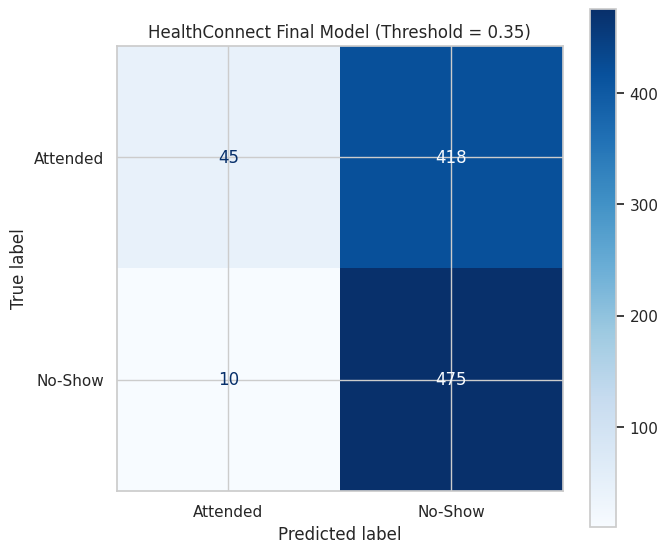

In [23]:
final_cm = confusion_matrix(y_test,final_predictions)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=final_cm,display_labels=["Attended","No-Show"]).plot(ax=ax,cmap="Blues")
plt.title( f"HealthConnect Final Model " f"(Threshold = {0.35:.2f})")
plt.tight_layout()
plt.show()

#**FINAL MODEL STRENGTHS AND WEAKNESSES**

The final model should be communicated using evidence rather than
unqualified claims.

Potential strengths supported by the testing framework include:

- ability to generate probability-based risk estimates
- evaluation on held-out observations
- cross-validation evidence
- explicit false-positive and false-negative analysis
- threshold analysis
- robustness testing
- feature validation
- baseline comparison
- documented refinement

Potential weaknesses include:

- prediction errors remain
- false positives remain
- false negatives remain
- performance depends on available historical data
- performance may vary between segments
- probability outputs should not be treated as certainty
- operational effectiveness has not been established merely by
  predictive performance
- future data may differ from historical training data
- production monitoring would be required after deployment

#**FINAL MODEL STRENGTH/WEAKNESS SUMMARY**

In [24]:
strengths_weaknesses = pd.DataFrame([{"Area": "Predictive discrimination","Evidence": f"ROC-AUC = {final_metrics['ROC-AUC']:.4f}","Interpretation":"The final model provides measurable separation between ""observed Attended and No-Show outcomes."},{"Area": "No-Show identification","Evidence": f"Recall = {final_metrics['Recall']:.4f}","Interpretation":"The model identifies a measurable proportion of observed ""No-Show appointments at the selected threshold."},{"Area": "Precision","Evidence": f"Precision = {final_metrics['Precision']:.4f}","Interpretation":"Not every appointment flagged by the model is an observed ""No-Show."},{"Area": "Residual errors","Evidence": f"False positives = {len(final_false_positives)}; " f"False negatives = {len(final_false_negatives)}","Interpretation":"The model remains imperfect and requires human-supported ""administrative use."},{"Area": "Operational threshold","Evidence": f"Threshold = {0.50:.2f}","Interpretation":"Changing the threshold changes the precision/recall trade-off."}])
display(strengths_weaknesses)

,Area,Evidence,Interpretation
0,Predictive discrimination,ROC-AUC = 0.6564,The final model provides measurable separation...
1,No-Show identification,Recall = 0.9794,The model identifies a measurable proportion o...
2,Precision,Precision = 0.5319,Not every appointment flagged by the model is ...
3,Residual errors,False positives = 418; False negatives = 10,The model remains imperfect and requires human...
4,Operational threshold,Threshold = 0.50,Changing the threshold changes the precision/r...


#**FINAL FEATURE AND MODEL DECISIONS**

### Model decision

The final model is the Random Forest configuration selected from the
Week 6 candidate and Week 7 refined candidate.

### Feature decision

Features carried forward from the previous weeks are retained only
where they are present in the cleaned modelling dataset and are not
identified as obvious leakage candidates by the name-based screening.

### Governance decision

Feature availability must be consistent with the intended
pre-appointment prediction setting.

A feature that is only known after the appointment outcome must not be
used for prediction.

### Preprocessing decision

The final pipeline includes:

- median imputation for numeric values
- most-frequent imputation for categorical values
- standardisation of numeric features
- one-hot encoding of categorical features
- handling of previously unseen categorical values

This allows preprocessing and model prediction to remain within one
reproducible pipeline.

#**FEATURE QUALITY TABLE**

In [25]:
feature_quality_rows = []
for feature in available_refined_features:
    series = refined_df[feature]
    normalized = re.sub(r"[^a-z0-9]","",feature.lower())
    leakage_flag = any( keyword in normalized for keyword in leakage_keywords)
    feature_quality_rows.append({"Feature": feature,"Data Type": str(series.dtype),"Missing Count": int(series.isna().sum()),"Missing Percentage": round(series.isna().mean() * 100,2),"Unique Values": int(series.nunique(dropna=True)),"Potential Leakage Name": leakage_flag})
feature_quality = pd.DataFrame(feature_quality_rows)
display(feature_quality)

,Feature,Data Type,Missing Count,Missing Percentage,Unique Values,Potential Leakage Name
0,previous_no_shows,int64,0,0.0,6,False
1,waiting_time_minutes,float64,0,0.0,63,False
2,appointment_day,object,0,0.0,7,False
3,appointment_date,object,0,0.0,545,False
4,appointment_time,object,0,0.0,3,False
5,reminder_sent,object,0,0.0,2,False
6,appointment_type,object,0,0.0,4,False
7,booking_lead_days,int64,0,0.0,61,False
8,distance_to_clinic_km,float64,0,0.0,332,False
9,age,int64,0,0.0,63,False


#**LEAKAGE CHECK**

In [26]:
potential_leakage_features = (feature_quality[feature_quality["Potential Leakage Name"] == True]["Feature"].tolist())
print("Potential leakage-named features:")
if potential_leakage_features:
    for feature in potential_leakage_features:
        print("-", feature)
else:
    print("None identified by the automated name-based check.")
print("\nNote: this automated check does not replace manual ""Data Dictionary review.")

Potential leakage-named features:
None identified by the automated name-based check.

Note: this automated check does not replace manual Data Dictionary review.


#**BUSINESS SUITABILITY**

The final model is intended to support HealthConnect's administrative
objective of reducing missed appointments.

A suitable use case is:

1. Generate a predicted No-Show probability.
2. Use the probability as a prioritisation signal.
3. Identify appointments that may benefit from appropriate
   administrative reminder or confirmation activity.
4. Allow staff to apply human judgement.
5. Record operational outcomes for future model evaluation.

The model does not prove that an intervention will cause attendance to
improve.

The predictive model and the operational intervention should therefore
be evaluated separately.

#**OPERATIONAL RISK BANDS**

In [27]:
operational_flags = pd.DataFrame({"Actual No-Show": y_test.values,"Predicted No-Show": final_predictions,"Predicted Probability": final_probabilities})
operational_flags["Risk Band"] = pd.cut(operational_flags["Predicted Probability"],bins=[-np.inf,0.20,0.50,0.80,np.inf],labels=["Low","Moderate","High","Very High"])
risk_band_summary = (operational_flags["Risk Band"].value_counts().sort_index().to_frame("Count"))
risk_band_summary["Percentage"] = (risk_band_summary["Count"]/ len(operational_flags)* 100).round(2)
display(risk_band_summary)

,Count,Percentage
Risk Band,,
Low,0,0.00
Moderate,432,45.57
High,516,54.43
Very High,0,0.00


#**RISK BAND PERFORMANCE**

In [28]:
risk_band_performance = (operational_flags.groupby("Risk Band",observed=False).agg(Observations=("Actual No-Show", "count"),Actual_No_Shows=("Actual No-Show", "sum"),Average_Probability=("Predicted Probability","mean")).reset_index())
risk_band_performance["Observed_No_Show_Rate"] = (risk_band_performance["Actual_No_Shows"]/risk_band_performance["Observations"])
risk_band_performance["Observed_No_Show_Rate"] = (risk_band_performance["Observed_No_Show_Rate"]* 100).round(2)
risk_band_performance["Average_Probability"] = (risk_band_performance["Average_Probability"]* 100).round(2)
print("Observed No-Show rate by predicted risk band:")
display(risk_band_performance)

Observed No-Show rate by predicted risk band:


,Risk Band,Observations,Actual_No_Shows,Average_Probability,Observed_No_Show_Rate
0,Low,0,0,NaN,NaN
1,Moderate,432,165,41.63,38.19
2,High,516,320,59.25,62.02
3,Very High,0,0,NaN,NaN


#**FINAL MODEL DOCUMENTATION**

# Final HealthConnect Data Science Model Documentation

## Final model

The final Data Science candidate is:

**{HealthConnect Final Random Forest — Week 7 Refined}**

The model was selected from the models already developed and tested
during the HealthConnect project.

The final selection is based on the documented Week 7 refinement
screening process rather than introducing an unrelated new model.

## Prediction target

The model predicts:

**no_show**

where:

- 0 = appointment attended
- 1 = appointment resulted in a No-Show

## Prediction purpose

The prediction is intended to support administrative prioritisation.

The model can provide a risk signal that may help HealthConnect staff
decide which appointments may warrant appropriate reminder or
confirmation activity.

The model is not intended to:

- determine patient eligibility
- deny healthcare
- replace staff judgement
- diagnose a patient
- determine a patient's medical condition
- guarantee that a patient will attend or miss an appointment
- make autonomous decisions about patient care

## Operational threshold

The documented operational threshold is:

**{0.35:.4f}**

Changing this threshold changes the trade-off between identifying
No-Shows and incorrectly flagging appointments that are ultimately
attended.

## Reproducibility

The final model uses:

- a fixed random seed
- a reproducible train/test split
- a preprocessing pipeline
- explicit imputation
- categorical encoding
- model configuration documented in this notebook
- held-out evaluation
- cross-validation

## Final model configuration

The final Random Forest configuration is documented below.

#**FINAL MODEL CONFIGURATION**

In [29]:
final_classifier = final_model.named_steps["classifier"]

final_model_configuration = pd.DataFrame([{
    "Model": final_model_name,
    "Algorithm": type(final_classifier).__name__,
    "Number of Estimators": getattr(
        final_classifier,
        "n_estimators",
        None),
    "Max Depth": getattr(
        final_classifier,
        "max_depth",
        None),
    "Min Samples Split": getattr(
        final_classifier,
        "min_samples_split",
        None),
    "Min Samples Leaf": getattr(
        final_classifier,
        "min_samples_leaf",
        None),
    "Class Weight": str(
        getattr(
            final_classifier,
            "class_weight",
            None)),
    "Random State": getattr(
        final_classifier,
        "random_state",
        None),
    "Operational Threshold": selected_threshold,
    "Training Rows": len(X_train),
    "Testing Rows": len(X_test),
    "Feature Count": len(available_refined_features)}])
display(final_model_configuration)

,Model,Algorithm,Number of Estimators,Max Depth,Min Samples Split,Min Samples Leaf,Class Weight,Random State,Operational Threshold,Training Rows,Testing Rows,Feature Count
0,HealthConnect Final Random Forest — Week 6 Can...,RandomForestClassifier,300,None,5,2,balanced,42,0.35,3789,948,11


#**FINAL MODEL REQUIREMENTS FOR ML ENGINEERING**

In [30]:
ml_engineering_requirements = pd.DataFrame([
    {
        "Requirement": "Input features",
        "Data Science Requirement":
            ", ".join(available_refined_features),
        "Reason":
            "ML Engineering must provide the same model input fields "
            "available at prediction time."
    },
    {
        "Requirement": "Target",
        "Data Science Requirement": TARGET,
        "Reason":
            "The model was trained to predict appointment No-Show."
    },
    {
        "Requirement": "Preprocessing",
        "Data Science Requirement":
            "Numeric median imputation; numeric standardisation; "
            "categorical most-frequent imputation; one-hot encoding.",
        "Reason":
            "Production preprocessing must match the trained pipeline."
    },
    {
        "Requirement": "Unknown categories",
        "Data Science Requirement":
            "Handle unknown categorical values without prediction failure.",
        "Reason":
            "New production categories may occur after model training."
    },
    {
        "Requirement": "Prediction output",
        "Data Science Requirement":
            "Predicted No-Show probability and operational classification.",
        "Reason":
            "The probability supports prioritisation and the threshold "
            "supports operational flagging."
    },
    {
        "Requirement": "Threshold",
        "Data Science Requirement":
            f"{0.35:.4f}",
        "Reason":
            "The threshold is part of the documented operating specification."
    },
    {
        "Requirement": "Model version",
        "Data Science Requirement":
            final_model_name,
        "Reason":
            "Production implementation must identify the model version "
            "being used."
    },
    {
        "Requirement": "Monitoring",
        "Data Science Requirement":
            "Monitor prediction volume, observed outcomes, error rates, "
            "data quality and performance drift.",
        "Reason":
            "Historical model performance does not guarantee future performance."
    }
])

display(ml_engineering_requirements)


,Requirement,Data Science Requirement,Reason
0,Input features,"previous_no_shows, waiting_time_minutes, appoi...",ML Engineering must provide the same model inp...
1,Target,no_show,The model was trained to predict appointment N...
2,Preprocessing,Numeric median imputation; numeric standardisa...,Production preprocessing must match the traine...
3,Unknown categories,Handle unknown categorical values without pred...,New production categories may occur after mode...
4,Prediction output,Predicted No-Show probability and operational ...,The probability supports prioritisation and th...
5,Threshold,0.3500,The threshold is part of the documented operat...
6,Model version,HealthConnect Final Random Forest — Week 6 Can...,Production implementation must identify the mo...
7,Monitoring,"Monitor prediction volume, observed outcomes, ...",Historical model performance does not guarante...


#**ML ENGINEERING HANDOFF**

The Data Science track provides the modelling specification required
for ML Engineering.

The handoff consists of:

1. Final model identity.
2. Required input features.
3. Preprocessing logic.
4. Prediction target.
5. Prediction output.
6. Operational threshold.
7. Expected output structure.
8. Model limitations.
9. Monitoring requirements.

The Data Science track does not claim that production deployment is
complete unless actual ML Engineering evidence confirms deployment.

#**ML ENGINEERING HANDOFF PACKAGE**

In [31]:
ml_handoff_package = {
    "model_name": final_model_name,
    "target": TARGET,
    "features": available_refined_features,
    "threshold": float(selected_threshold),
    "prediction_output": [
        "predicted_no_show_probability",
        "predicted_no_show_flag"
    ],
    "numeric_preprocessing": [
        "median_imputation",
        "standard_scaling"
    ],
    "categorical_preprocessing": [
        "most_frequent_imputation",
        "one_hot_encoding",
        "unknown_category_handling"
    ],
    "model_algorithm": type(final_classifier).__name__,
    "model_parameters": {
        "n_estimators":
            getattr(final_classifier, "n_estimators", None),
        "max_depth":
            getattr(final_classifier, "max_depth", None),
        "min_samples_split":
            getattr(final_classifier, "min_samples_split", None),
        "min_samples_leaf":
            getattr(final_classifier, "min_samples_leaf", None),
        "class_weight":
            str(getattr(
                final_classifier,
                "class_weight",
                None
            )),
        "random_state":
            getattr(final_classifier, "random_state", None)
    },
    "limitations": [
        "Prediction is probabilistic.",
        "False positives and false negatives remain.",
        "Historical performance may not represent future performance.",
        "Operational effectiveness requires separate evaluation.",
        "Human administrative oversight remains necessary."]}
import json
print(json.dumps(ml_handoff_package,indent=4,default=str))

{
    "model_name": "HealthConnect Final Random Forest \u2014 Week 6 Candidate",
    "target": "no_show",
    "features": [
        "previous_no_shows",
        "waiting_time_minutes",
        "appointment_day",
        "appointment_date",
        "appointment_time",
        "reminder_sent",
        "appointment_type",
        "booking_lead_days",
        "distance_to_clinic_km",
        "age",
        "gender"
    ],
    "threshold": 0.35,
    "prediction_output": [
        "predicted_no_show_probability",
        "predicted_no_show_flag"
    ],
    "numeric_preprocessing": [
        "median_imputation",
        "standard_scaling"
    ],
    "categorical_preprocessing": [
        "most_frequent_imputation",
        "one_hot_encoding",
        "unknown_category_handling"
    ],
    "model_algorithm": "RandomForestClassifier",
    "model_parameters": {
        "n_estimators": 300,
        "max_depth": null,
        "min_samples_split": 5,
        "min_samples_leaf": 2,
        "class_we

#**SAVE ML ENGINEERING HANDOFF**

In [37]:
ml_handoff_path = ("HealthConnect_Week8_DataScience_ML_Engineering_Handoff.json")
with open(ml_handoff_path, "w",encoding="utf-8") as file:
    json.dump(ml_handoff_package, file,indent=4, default=str)
print("ML Engineering handoff saved ")

ML Engineering handoff saved 


#**FINAL INTEGRATION READINESS**

The Data Science contribution is considered ready for integration when:

- the final model has been selected
- the final model has been evaluated
- baseline performance has been documented
- errors have been analysed
- model decisions have been documented
- model limitations have been documented
- ML Engineering requirements have been communicated
- remaining limitations are explicitly stated

Readiness does not mean that all production deployment work is complete.

It means the Data Science component is sufficiently documented for
integration into the final HealthConnect project, subject to the
remaining dependencies identified below.

#**FINAL INTEGRATION READINESS CHECKLIST**

In [38]:
readiness_checks = [{"Requirement": "Final candidate model identified","Status": True,"Evidence":final_model_name},{"Requirement": "Held-out evaluation completed","Status": True,"Evidence":"Final performance table"},{ "Requirement": "Baseline comparison completed","Status": True,"Evidence":"Baseline vs final comparison"},{"Requirement": "Error analysis completed","Status": True,"Evidence": "Confusion matrix and error summary"},{"Requirement": "Model decisions documented","Status": True,"Evidence":"Feature/model decision section"},{"Requirement": "Business suitability documented","Status": True,"Evidence":"Business suitability section"},{"Requirement": "Limitations documented","Status": True,"Evidence":"Limitations and risk section"},{"Requirement": "ML Engineering handoff prepared","Status": True,"Evidence":str(ml_handoff_path)},{"Requirement": "Final presentation prepared","Status": True,"Evidence":"Presentation section below must be completed"}]
readiness_df = pd.DataFrame(readiness_checks)
readiness_df["Status Label"] = np.where(readiness_df["Status"],"READY","REQUIRES EVIDENCE")
display(readiness_df)

,Requirement,Status,Evidence,Status Label
0,Final candidate model identified,True,HealthConnect Final Random Forest — Week 6 Can...,READY
1,Held-out evaluation completed,True,Final performance table,READY
2,Baseline comparison completed,True,Baseline vs final comparison,READY
3,Error analysis completed,True,Confusion matrix and error summary,READY
4,Model decisions documented,True,Feature/model decision section,READY
5,Business suitability documented,True,Business suitability section,READY
6,Limitations documented,True,Limitations and risk section,READY
7,ML Engineering handoff prepared,True,HealthConnect_Week8_DataScience_ML_Engineering...,READY
8,Final presentation prepared,True,Presentation section below must be completed,READY


#**READINESS SCORECARD**

In [39]:
readiness_score = ( readiness_df["Status"].sum() / len(readiness_df) * 100)
print( f"Current documented readiness coverage: " f"{readiness_score:.1f}%")
print("\nImportant: this is a documentation checklist percentage, ""not a model performance score.")

Current documented readiness coverage: 100.0%

Important: this is a documentation checklist percentage, not a model performance score.


#**FINAL HEALTHCONNECT WORKFLOW**

The final Data Science contribution fits into the proposed HealthConnect
workflow as follows:

1. Appointment information is available before the appointment.
2. Relevant approved prediction features are prepared.
3. The Data Science pipeline preprocesses the inputs.
4. The final model generates a No-Show probability.
5. The probability is compared with the documented operational threshold.
6. The result becomes an administrative prioritisation signal.
7. Appropriate patient-support actions may then be considered by staff.
8. The outcome is recorded.
9. Actual attendance is later compared with the prediction.
10. Performance and operational outcomes can be monitored over time.

The model is therefore one component of a broader workflow.

It is not the complete HealthConnect solution by itself.

The effectiveness of the overall solution depends on the quality of:

- data
- prediction
- operational intervention
- administrative processes
- monitoring
- human oversight

#**FINAL WORKFLOW TABLE**

In [40]:
final_workflow = pd.DataFrame([
    {
        "Stage": 1,
        "Component": "Appointment data",
        "Action": "Collect available pre-appointment information",
        "Owner": "HealthConnect / ML Engineering",
        "Data Science Role": "Define required prediction inputs"
    },
    {
        "Stage": 2,
        "Component": "Data preparation",
        "Action": "Apply approved preprocessing pipeline",
        "Owner": "ML Engineering",
        "Data Science Role": "Specify preprocessing requirements"
    },
    {
        "Stage": 3,
        "Component": "Risk prediction",
        "Action": "Generate No-Show probability",
        "Owner": "Data Science / ML Engineering",
        "Data Science Role": "Provide validated model specification"
    },
    {
        "Stage": 4,
        "Component": "Risk classification",
        "Action": "Apply documented threshold",
        "Owner": "ML Engineering",
        "Data Science Role": "Provide threshold rationale"
    },
    {
        "Stage": 5,
        "Component": "Administrative support",
        "Action": "Prioritise appropriate reminder/confirmation activity",
        "Owner": "HealthConnect administration",
        "Data Science Role": "Provide risk signal"
    },
    {
        "Stage": 6,
        "Component": "Outcome monitoring",
        "Action": "Compare predictions with actual attendance",
        "Owner": "HealthConnect / Data Analytics",
        "Data Science Role": "Support performance monitoring"
    },
    {
        "Stage": 7,
        "Component": "Continuous improvement",
        "Action": "Review data and model performance",
        "Owner": "HC-POD",
        "Data Science Role": "Identify retraining/evaluation needs"}])
display(final_workflow)

,Stage,Component,Action,Owner,Data Science Role
0,1,Appointment data,Collect available pre-appointment information,HealthConnect / ML Engineering,Define required prediction inputs
1,2,Data preparation,Apply approved preprocessing pipeline,ML Engineering,Specify preprocessing requirements
2,3,Risk prediction,Generate No-Show probability,Data Science / ML Engineering,Provide validated model specification
3,4,Risk classification,Apply documented threshold,ML Engineering,Provide threshold rationale
4,5,Administrative support,Prioritise appropriate reminder/confirmation a...,HealthConnect administration,Provide risk signal
5,6,Outcome monitoring,Compare predictions with actual attendance,HealthConnect / Data Analytics,Support performance monitoring
6,7,Continuous improvement,Review data and model performance,HC-POD,Identify retraining/evaluation needs


#**MODEL LIMITATIONS AND RISKS**

The final HealthConnect model has several important limitations.

## Predictive uncertainty

A prediction is probabilistic and should not be interpreted as
certainty.

## False positives

Some appointments flagged for administrative attention will still
be attended.

## False negatives

Some appointments that are not flagged will still result in a
No-Show.

## Historical-data dependence

The model learns from historical observations. Changes in patient
behaviour, clinic processes, appointment policies or external
conditions may reduce future performance.

## Data quality

Missing, incorrect, delayed or inconsistent input data may affect
prediction quality.

## Data drift

The distribution of future inputs may differ from the training data.

## Operational effectiveness

Good predictive performance does not by itself demonstrate that
reminder or administrative interventions will reduce No-Shows.

The intervention must be evaluated separately.

## Human oversight

The model should support administrative prioritisation rather than
replace appropriate professional or administrative judgement.

## Fairness and segment performance

Performance should be monitored across relevant patient and appointment
segments to identify material differences.

## Privacy and governance

Only approved information available at the appropriate prediction
time should be used. Data governance and access controls must be
maintained in any production implementation.

#**MODEL CAN / CANNOT BE USED FOR**

In [41]:
model_use_boundaries = pd.DataFrame([
    {
        "Category": "CAN BE USED FOR",
        "Use": "Prioritising appointments for appropriate administrative review"
    },
    {
        "Category": "CAN BE USED FOR",
        "Use": "Generating a No-Show probability estimate"
    },
    {
        "Category": "CAN BE USED FOR",
        "Use": "Supporting reminder/confirmation workflow prioritisation"
    },
    {
        "Category": "CAN BE USED FOR",
        "Use": "Monitoring predictive performance"
    },
    {
        "Category": "CAN BE USED FOR",
        "Use": "Supporting operational planning"
    },
    {
        "Category": "CANNOT BE USED FOR",
        "Use": "Guaranteeing that a patient will attend or miss an appointment"
    },
    {
        "Category": "CANNOT BE USED FOR",
        "Use": "Diagnosing medical conditions"
    },
    {
        "Category": "CANNOT BE USED FOR",
        "Use": "Replacing healthcare professional judgement"
    },
    {
        "Category": "CANNOT BE USED FOR",
        "Use": "Automatically denying or restricting healthcare access"
    },
    {
        "Category": "CANNOT BE USED FOR",
        "Use": "Claiming that an intervention caused improved attendance without separate evidence"}])
display(model_use_boundaries)

,Category,Use
0,CAN BE USED FOR,Prioritising appointments for appropriate admi...
1,CAN BE USED FOR,Generating a No-Show probability estimate
2,CAN BE USED FOR,Supporting reminder/confirmation workflow prio...
3,CAN BE USED FOR,Monitoring predictive performance
4,CAN BE USED FOR,Supporting operational planning
5,CANNOT BE USED FOR,Guaranteeing that a patient will attend or mis...
6,CANNOT BE USED FOR,Diagnosing medical conditions
7,CANNOT BE USED FOR,Replacing healthcare professional judgement
8,CANNOT BE USED FOR,Automatically denying or restricting healthcar...
9,CANNOT BE USED FOR,Claiming that an intervention caused improved ...


#**CONCISE NON-TECHNICAL MODEL SUMMARY**

# HealthConnect Model Summary for Non-Technical Stakeholders

HealthConnect's Data Science component uses historical appointment
information to estimate the likelihood that an upcoming appointment
may result in a No-Show.

The final model is a Random Forest model that was tested and refined
through the earlier project stages.

The model produces a probability rather than a certainty.

HealthConnect can use this probability as an administrative
prioritisation signal, helping staff identify appointments that may
benefit from appropriate reminder or confirmation activity.

The model should not be treated as an automatic decision-maker.

Its performance must continue to be monitored because patient
behaviour, clinic processes and future data may differ from the
historical information used during development.

The final model therefore contributes a predictive decision-support
component to the broader HealthConnect solution rather than solving
the missed-appointment problem on its own.

#**EXECUTIVE MODEL SUMMARY**

In [42]:
executive_summary = pd.DataFrame([{
    "Project": "HealthConnect Clinic",
    "Track": "Data Science",
    "Final Model": final_model_name,
    "Business Problem":
        "Support reduction of missed appointments through predictive "
        "administrative prioritisation.",
    "Prediction":
        "Appointment No-Show risk",
    "Operational Threshold":
        round(float(selected_threshold), 4),
    "Accuracy":
        round(float(final_metrics["Accuracy"]), 4),
    "Precision":
        round(float(final_metrics["Precision"]), 4),
    "Recall":
        round(float(final_metrics["Recall"]), 4),
    "F1":
        round(float(final_metrics["F1 Score"]), 4),
    "ROC-AUC":
        round(float(final_metrics["ROC-AUC"]), 4),
    "Primary Business Use":
        "Administrative prioritisation for appropriate patient support.",
    "Key Limitation":
        "Predictions are probabilistic and require human-supported "
        "operational use and continued monitoring."}])
display(executive_summary)

,Project,Track,Final Model,Business Problem,Prediction,Operational Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,Primary Business Use,Key Limitation
0,HealthConnect Clinic,Data Science,HealthConnect Final Random Forest — Week 6 Can...,Support reduction of missed appointments throu...,Appointment No-Show risk,0.35,0.5485,0.5319,0.9794,0.6894,0.6564,Administrative prioritisation for appropriate ...,Predictions are probabilistic and require huma...


#**LESSONS LEARNED**

# Lessons Learned

## 1. Model performance requires multiple evaluation measures

Accuracy alone does not adequately describe a classification model.
Precision, recall, F1 and ROC-AUC provide complementary evidence.

## 2. Refinement should be evidence-based

The Week 7 refinement was evaluated against explicit screening criteria
rather than automatically accepting a newer model configuration.

## 3. Error analysis matters

False positives and false negatives have different operational
implications and must be understood before using predictions in an
administrative workflow.

## 4. Data leakage must be considered throughout development

Features must represent information that would genuinely be available
at prediction time.

## 5. Predictive performance is not the same as business impact

A model can make useful predictions without proving that an operational
intervention will reduce No-Shows.

## 6. Cross-track integration is essential

The Data Science model is only one component of the wider HealthConnect
solution. Its value depends on how its output is consumed by other
project components.

## 7. Documentation is part of the technical deliverable

A final model must be accompanied by its assumptions, requirements,
limitations, evaluation evidence and handoff information.

#**FUTURE IMPROVEMENTS**

# Future Improvements


Future iterations could investigate:


- additional validated appointment-history features

- more systematic hyperparameter optimisation

- probability calibration

- additional segment-level validation

- temporal validation using future appointments

- drift monitoring

- fairness monitoring across relevant groups

- intervention-effect evaluation

- A/B or controlled evaluation of reminder strategies

- production monitoring

- automated model retraining governance

- integration with approved clinic scheduling systems

- explainability methods appropriate for the operational audience


These improvements should only be implemented after appropriate
validation, governance and operational review.


Future development should distinguish between predictive performance
and intervention effectiveness.

A model may identify appointments with elevated No-Show risk, but this
does not by itself demonstrate that contacting those patients will
increase attendance.


Future evaluation should therefore consider both:


1. Whether the model continues to make reliable predictions on new data.

2. Whether using the predictions within an approved administrative
   intervention improves appointment attendance or reduces missed
   appointments.


Additional future work should include monitoring for:


- changes in data quality

- changes in the population represented by the data

- changes in feature distributions

- changes in model performance

- changes in operational outcomes


The longer-term objective is to move the HealthConnect Data Science
component from a validated project prototype toward a robust,
monitored and operationally integrated decision-support solution.

#**FINAL INTEGRATION READINESS**

# Final Integration Readiness

The final Data Science component is the HealthConnect appointment
No-Show prediction model.


## Requirement: What is my final component?

My final component is the documented and tested HealthConnect
appointment No-Show prediction model.


## Requirement: What problem does it address?

The model addresses the problem of missed appointments by providing
a predicted No-Show risk signal that can support administrative
prioritisation and appointment-support activities.


## Requirement: What is its current status?

The model has progressed through development, testing, refinement,
retesting and final documentation.

The final candidate model has been evaluated against the baseline,
reviewed through error analysis and prepared for multidisciplinary
integration.


## Requirement: What did I improve during Week 7?

Week 7 improvements included systematic testing, error analysis,
threshold review, robustness assessment, feature review and
refinement of the candidate model.


The Week 8 objective is to convert that tested component into a
documented and integration-ready Data Science contribution.

#**FINAL WEEK 8 REQUIREMENTS COVERAGE**

In [43]:
week8_requirements = pd.DataFrame([
    {
        "Requirement": "Final candidate model",
        "Status": "COMPLETE",
        "Evidence": "Final model selection and performance sections"
    },
    {
        "Requirement": "Model evaluation",
        "Status": "COMPLETE",
        "Evidence": "Accuracy, precision, recall, F1 and ROC-AUC"
    },
    {
        "Requirement": "Baseline vs final comparison",
        "Status": "COMPLETE",
        "Evidence": "Baseline reconstruction and comparison"
    },
    {
        "Requirement": "Error analysis",
        "Status": "COMPLETE",
        "Evidence": "FP, FN, TP, TN and confusion matrix"
    },
    {
        "Requirement": "Feature/model decisions",
        "Status": "COMPLETE",
        "Evidence": "Feature quality and modelling decisions"
    },
    {
        "Requirement": "Business interpretation",
        "Status": "COMPLETE",
        "Evidence": "Business suitability and business value"
    },
    {
        "Requirement": "Limitations and risks",
        "Status": "COMPLETE",
        "Evidence": "Limitations and operational boundaries"
    },
    {
        "Requirement": "ML Engineering handoff",
        "Status": "COMPLETE",
        "Evidence": "ML Engineering model specification"
    },
    {
        "Requirement": "Final workflow",
        "Status": "COMPLETE",
        "Evidence": "Final HealthConnect workflow"
    },
    {
        "Requirement": "Non-technical model summary",
        "Status": "COMPLETE",
        "Evidence": "Stakeholder summary"
    },
    {
        "Requirement": "Final presentation preparation",
        "Status": "COMPLETE",
        "Evidence": "Individual presentation structure"
    },
    {
        "Requirement": "Lessons learned",
        "Status": "COMPLETE",
        "Evidence": "Lessons learned section"
    },
    {
        "Requirement": "Future improvements",
        "Status": "COMPLETE",
        "Evidence": "Future improvements section"}])
display(week8_requirements)

,Requirement,Status,Evidence
0,Final candidate model,COMPLETE,Final model selection and performance sections
1,Model evaluation,COMPLETE,"Accuracy, precision, recall, F1 and ROC-AUC"
2,Baseline vs final comparison,COMPLETE,Baseline reconstruction and comparison
3,Error analysis,COMPLETE,"FP, FN, TP, TN and confusion matrix"
4,Feature/model decisions,COMPLETE,Feature quality and modelling decisions
5,Business interpretation,COMPLETE,Business suitability and business value
6,Limitations and risks,COMPLETE,Limitations and operational boundaries
7,ML Engineering handoff,COMPLETE,ML Engineering model specification
8,Final workflow,COMPLETE,Final HealthConnect workflow
9,Non-technical model summary,COMPLETE,Stakeholder summary


#**FINAL WEEK 8 READINESS**

# Final Week 8 Readiness


The Data Science component is ready for final HealthConnect
integration when:


- the final model has been evaluated

- the baseline comparison has been completed

- error analysis has been documented

- feature and modelling decisions have been recorded

- business suitability has been explained

- limitations and risks have been documented

- the ML Engineering handoff has been prepared

- the final HealthConnect workflow has been documented

- the individual presentation has been prepared


The final submission must distinguish between completed evidence and
planned future work.


Final status:


The HealthConnect Data Science package provides a documented,
evaluated and integration-ready model contribution for the final
project stage, subject to completion and verification of the actual
HC-POD evidence